# Задание Light, бибилиотека Pytorch

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import os
import gdown

device = torch.device('cuda')

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'
'(О. Генри) Обучающая_50 вместе.txt'
'(О. Генри) Тестовая_20 вместе.txt'
'(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Стругацкие) Обучающая_5 вместе.txt'
'(Стругацкие) Тестовая_2 вместе.txt'


In [ ]:
# настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # признак тестовой выборки в имени файла

# загрузка датасета
CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    # выделение имени класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # если выделение получилось, то файл обрабатывается
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        # пПроверка типа выборки в имени файла
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # если тип выборки обучающая либо тестовая - файл обрабатывается
        if is_train or is_test:
            # добавление нового класса, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                # инициализация соответствующих классу строк текста
                text_train.append('')
                text_test.append('')

            # поиск индекса класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                # загрузка содержимого файла в строку
                text = f.read()
            # определение выборки, куда будет добавлено содержимое
            subset = text_train if is_train else text_test
            # добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

# определение количества классов
CLASS_COUNT = len(CLASS_LIST)

Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе

<>:14: SyntaxWarning: invalid escape sequence '\('
<>:14: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2312/1261361779.py:14: SyntaxWarning: invalid escape sequence '\('
  m = re.match('\((.+)\) (\S+)_', file_name)


In [ ]:
# класс для упрощения подготовки данных
class DataProcessor:
  def __init__(self, vocab_size, win_size, win_hop):
    self.vocab_size = vocab_size
    self.win_size = win_size
    self.win_hop = win_hop

    self.word_to_index = {}

  # очистка текста и деление на слова
  def text_to_words(self, text):
    text = text.lower()

    # остаются только буквы и цифры
    words = re.findall(r'[а-яёa-z0-9]+', text)

    return words

  # создание словаря по обучающим текстам
  def fit_tokenizer(self, text_train):
    counter = Counter()

    for text in text_train:
      words = self.text_to_words(text)
      counter.update(words)

    # 0 остается для неизвестных слов
    most_common_words = counter.most_common(self.vocab_size - 1)

    self.word_to_index = {'unknown': 0}

    for index, pair in enumerate(most_common_words, start=1):
      word = pair[0]
      self.word_to_index[word] = index

  # перевод текста в список чисел
  def text_to_sequence(self, text):
    words = self.text_to_words(text)

    sequence = []

    for word in words:
      index = self.word_to_index.get(word, 0)
      sequence.append(index)

    return sequence

  # нарезка одного текста на окна
  def split_sequence(self, sequence):
    result = []

    for i in range(0, len(sequence) - self.win_size + 1, self.win_hop):
      result.append(sequence[i:i + self.win_size])

    return result

  # нарезка всех текстов и создание меткок классов
  def vectorize_sequence(self, seq_list):
    x = []
    y = []

    class_count = len(seq_list)

    for class_index in range(class_count):
      windows = self.split_sequence(seq_list[class_index])

      x += windows
      y += [class_index] * len(windows)

    return x, y

  # перевод окна в bag of words
  def sequences_to_bow(self, sequences):
    x_bow = np.zeros((len(sequences), self.vocab_size), dtype=np.float32)

    for i, sequence in enumerate(sequences):
      unique_words = set(sequence)

      for word_index in unique_words:
        if word_index < self.vocab_size:
          x_bow[i, word_index] = 1.0

    return x_bow

  # полная подготовка данных
  def prepare(self, text_train, text_test):
    self.fit_tokenizer(text_train)

    seq_train = []

    for text in text_train:
      seq_train.append(self.text_to_sequence(text))

    seq_test = []

    for text in text_test:
      seq_test.append(self.text_to_sequence(text))

    x_train, y_train = self.vectorize_sequence(seq_train)
    x_test, y_test = self.vectorize_sequence(seq_test)

    x_train_01 = self.sequences_to_bow(x_train)
    x_test_01 = self.sequences_to_bow(x_test)

    y_train = np.array(y_train, dtype=np.int64)
    y_test = np.array(y_test, dtype=np.int64)

    print('VOCAB_SIZE:', self.vocab_size)
    print('WIN_SIZE:', self.win_size)
    print('WIN_HOP:', self.win_hop)
    print('x_train_01:', x_train_01.shape)
    print('y_train:', y_train.shape)
    print('x_test_01:', x_test_01.shape)
    print('y_test:', y_test.shape)

    return x_train_01, y_train, x_test_01, y_test

# создание загрузчиков данных
def create_loaders(x_train, y_train, x_test, y_test, batch_size):
  x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)

  x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test, dtype=torch.long)

  train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
  test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  return train_loader, test_loader

# модель для классификации текстов
class TextModel(nn.Module):
  def __init__(self, input_dim, class_count):
    super().__init__()

    self.layers = nn.Sequential(
      nn.Linear(input_dim, 256),
      nn.ReLU(),
      nn.BatchNorm1d(256),
      nn.Dropout(0.3),

      nn.Linear(256, 128),
      nn.ReLU(),
      nn.BatchNorm1d(128),
      nn.Dropout(0.3),

      nn.Linear(128, class_count)
    )

  def forward(self, x):
    return self.layers(x)


# создание модель
def create_model(input_dim, class_count):
  model = TextModel(input_dim, class_count)

  return model

# проверка модели на проверочных данных
def evaluate_model(model, data_loader, loss_function):
  model.eval()

  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for x_batch, y_batch in data_loader:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      outputs = model(x_batch)
      loss = loss_function(outputs, y_batch)

      total_loss += loss.item() * x_batch.size(0)

      predictions = torch.argmax(outputs, dim=1)

      correct += (predictions == y_batch).sum().item()
      total += y_batch.size(0)

  avg_loss = total_loss / total
  accuracy = correct / total

  return avg_loss, accuracy

# обучение
def train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001):
  model = model.to(device)

  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
  }

  for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()

      outputs = model(x_batch)
      loss = loss_function(outputs, y_batch)

      loss.backward()
      optimizer.step()

      total_loss += loss.item() * x_batch.size(0)

      predictions = torch.argmax(outputs, dim=1)

      correct += (predictions == y_batch).sum().item()
      total += y_batch.size(0)

    train_loss = total_loss / total
    train_accuracy = correct / total

    val_loss, val_accuracy = evaluate_model(
      model,
      test_loader,
      loss_function
    )

    history['accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(
      f"Эпоха {epoch + 1}/{epochs} | "
      f"точность: {train_accuracy:.5f} | "
      f"проверка: {val_accuracy:.5f} | "
      f"ошибка: {train_loss:.5f} | "
      f"ошибка проверки: {val_loss:.5f}"
    )

  return history

# графики обучения
def plot_history(history, vocab_size, win_size, win_hop):
  plt.figure(figsize=(8, 5))
  plt.plot(history['accuracy'], label='Точность на обучении')
  plt.plot(history['val_accuracy'], label='Точность на проверке')
  plt.title(
    f'График точности\n'
    f'VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}'
  )
  plt.xlabel('Эпоха')
  plt.ylabel('Точность')
  plt.legend()
  plt.grid(True)
  plt.show()

  plt.figure(figsize=(8, 5))
  plt.plot(history['loss'], label='Ошибка на обучении')
  plt.plot(history['val_loss'], label='Ошибка на проверке')
  plt.title(
    f'График ошибки\n'
    f'VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}'
  )
  plt.xlabel('Эпоха')
  plt.ylabel('Ошибка')
  plt.legend()
  plt.grid(True)
  plt.show()

VOCAB_SIZE: 10000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_01: (17641, 10000)
y_train: (17641,)
x_test_01: (6686, 10000)
y_test: (6686,)
Эпоха 1/15 | точность: 0.98339 | проверка: 0.89770 | ошибка: 0.07730 | ошибка проверки: 0.32215
Эпоха 2/15 | точность: 1.00000 | проверка: 0.89500 | ошибка: 0.00214 | ошибка проверки: 0.31147
Эпоха 3/15 | точность: 1.00000 | проверка: 0.89904 | ошибка: 0.00096 | ошибка проверки: 0.29840
Эпоха 4/15 | точность: 1.00000 | проверка: 0.89859 | ошибка: 0.00057 | ошибка проверки: 0.29401
Эпоха 5/15 | точность: 1.00000 | проверка: 0.89949 | ошибка: 0.00039 | ошибка проверки: 0.28865
Эпоха 6/15 | точность: 1.00000 | проверка: 0.89665 | ошибка: 0.00028 | ошибка проверки: 0.29911
Эпоха 7/15 | точность: 1.00000 | проверка: 0.90323 | ошибка: 0.00020 | ошибка проверки: 0.28055
Эпоха 8/15 | точность: 1.00000 | проверка: 0.90338 | ошибка: 0.00017 | ошибка проверки: 0.28119
Эпоха 9/15 | точность: 1.00000 | проверка: 0.90323 | ошибка: 0.00013 | ошибка проверки: 0.27644
Эпох

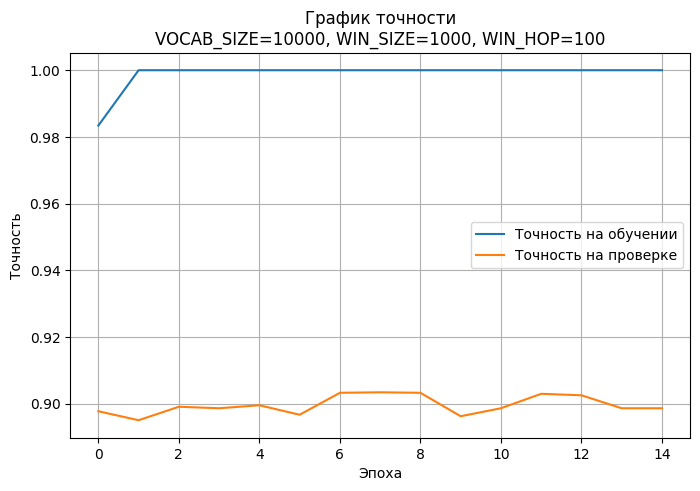

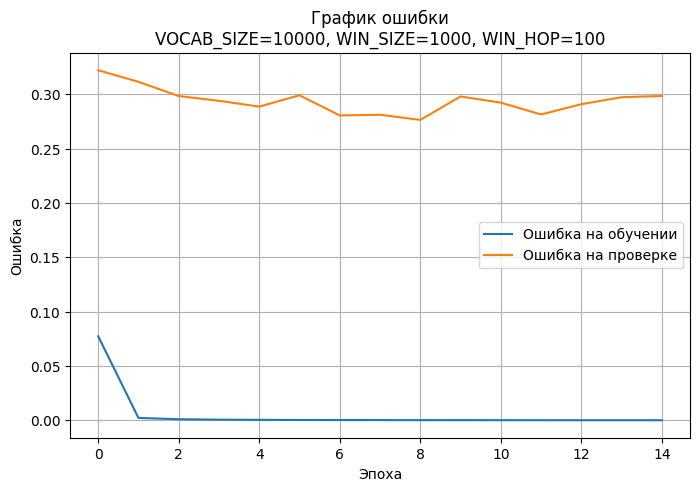

Лучшая точность: 0.9033801974274603


In [ ]:
results = []

VOCAB_SIZE = 10000
WIN_SIZE = 1000
WIN_HOP = 100

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 10000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_01: (7047, 10000)
y_train: (7047,)
x_test_01: (2664, 10000)
y_test: (2664,)
Эпоха 1/15 | точность: 0.96651 | проверка: 0.91667 | ошибка: 0.16102 | ошибка проверки: 0.33665
Эпоха 2/15 | точность: 1.00000 | проверка: 0.92793 | ошибка: 0.00662 | ошибка проверки: 0.28759
Эпоха 3/15 | точность: 1.00000 | проверка: 0.93018 | ошибка: 0.00380 | ошибка проверки: 0.28229
Эпоха 4/15 | точность: 1.00000 | проверка: 0.92155 | ошибка: 0.00249 | ошибка проверки: 0.27180
Эпоха 5/15 | точность: 1.00000 | проверка: 0.92005 | ошибка: 0.00156 | ошибка проверки: 0.27506
Эпоха 6/15 | точность: 1.00000 | проверка: 0.93093 | ошибка: 0.00107 | ошибка проверки: 0.24041
Эпоха 7/15 | точность: 1.00000 | проверка: 0.92192 | ошибка: 0.00086 | ошибка проверки: 0.26590
Эпоха 8/15 | точность: 0.99957 | проверка: 0.89715 | ошибка: 0.00165 | ошибка проверки: 0.31205
Эпоха 9/15 | точность: 1.00000 | проверка: 0.92230 | ошибка: 0.00075 | ошибка проверки: 0.26014
Эпоха 

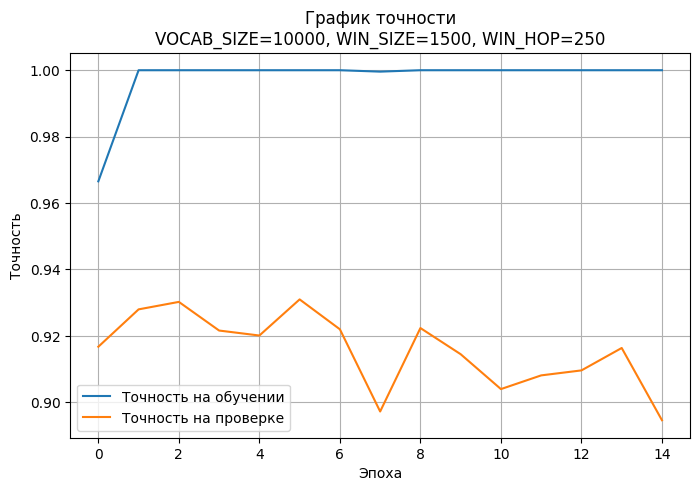

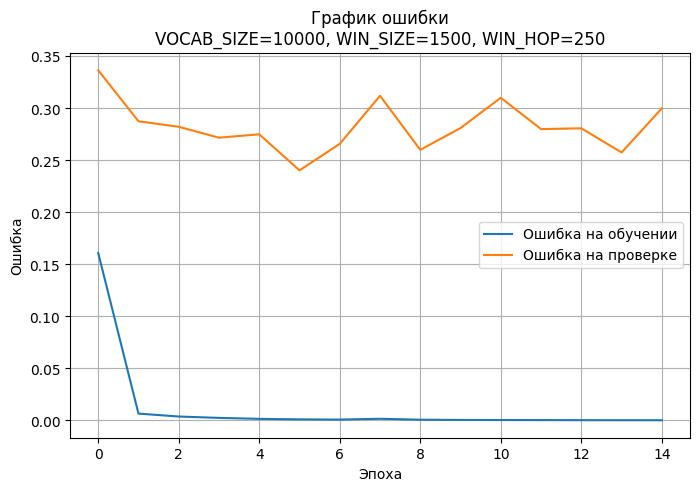

Лучшая точность: 0.9309309309309309


In [ ]:
VOCAB_SIZE = 10000
WIN_SIZE = 1500
WIN_HOP = 250


processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 10000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_01: (3520, 10000)
y_train: (3520,)
x_test_01: (1328, 10000)
y_test: (1328,)
Эпоха 1/15 | точность: 0.93551 | проверка: 0.87801 | ошибка: 0.28026 | ошибка проверки: 0.45445
Эпоха 2/15 | точность: 1.00000 | проверка: 0.90813 | ошибка: 0.01602 | ошибка проверки: 0.36172
Эпоха 3/15 | точность: 1.00000 | проверка: 0.90437 | ошибка: 0.00733 | ошибка проверки: 0.35432
Эпоха 4/15 | точность: 1.00000 | проверка: 0.90437 | ошибка: 0.00498 | ошибка проверки: 0.34353
Эпоха 5/15 | точность: 1.00000 | проверка: 0.91114 | ошибка: 0.00343 | ошибка проверки: 0.31936
Эпоха 6/15 | точность: 1.00000 | проверка: 0.91114 | ошибка: 0.00259 | ошибка проверки: 0.31541
Эпоха 7/15 | точность: 1.00000 | проверка: 0.91566 | ошибка: 0.00217 | ошибка проверки: 0.29370
Эпоха 8/15 | точность: 1.00000 | проверка: 0.91039 | ошибка: 0.00179 | ошибка проверки: 0.30229
Эпоха 9/15 | точность: 1.00000 | проверка: 0.91491 | ошибка: 0.00142 | ошибка проверки: 0.29130
Эпоха 

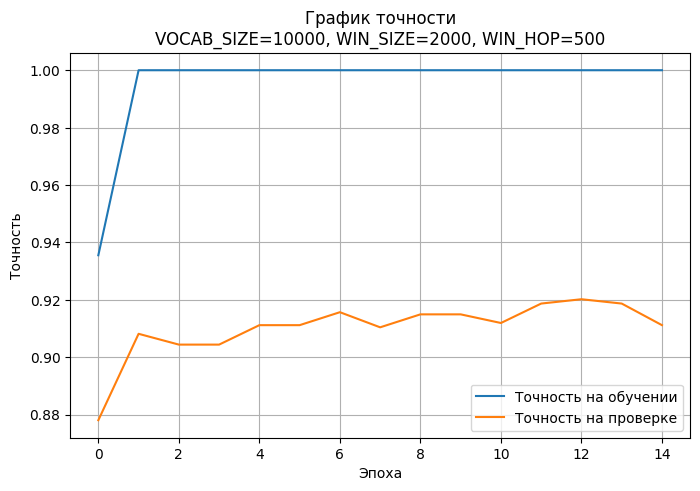

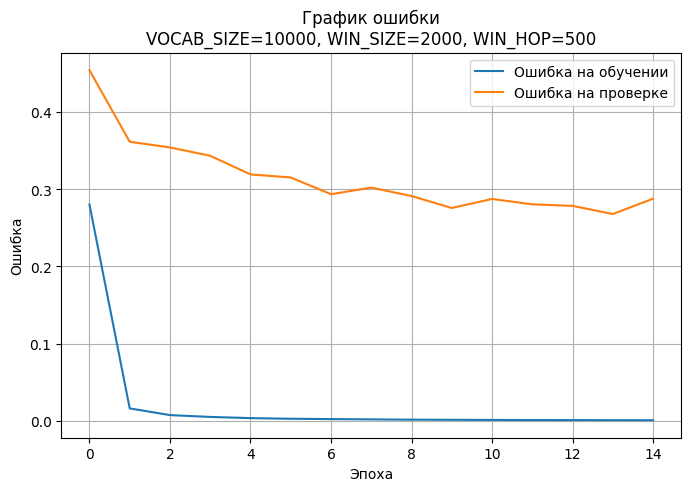

Лучшая точность: 0.9201807228915663


In [ ]:
VOCAB_SIZE = 10000
WIN_SIZE = 2000
WIN_HOP = 500

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 15000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_01: (17641, 15000)
y_train: (17641,)
x_test_01: (6686, 15000)
y_test: (6686,)
Эпоха 1/15 | точность: 0.98589 | проверка: 0.89650 | ошибка: 0.07226 | ошибка проверки: 0.33820
Эпоха 2/15 | точность: 1.00000 | проверка: 0.88304 | ошибка: 0.00207 | ошибка проверки: 0.35076
Эпоха 3/15 | точность: 1.00000 | проверка: 0.88409 | ошибка: 0.00090 | ошибка проверки: 0.32771
Эпоха 4/15 | точность: 1.00000 | проверка: 0.89082 | ошибка: 0.00052 | ошибка проверки: 0.32096
Эпоха 5/15 | точность: 1.00000 | проверка: 0.89261 | ошибка: 0.00033 | ошибка проверки: 0.30576
Эпоха 6/15 | точность: 1.00000 | проверка: 0.89560 | ошибка: 0.00025 | ошибка проверки: 0.29797
Эпоха 7/15 | точность: 1.00000 | проверка: 0.89725 | ошибка: 0.00020 | ошибка проверки: 0.29438
Эпоха 8/15 | точность: 1.00000 | проверка: 0.90398 | ошибка: 0.00016 | ошибка проверки: 0.28818
Эпоха 9/15 | точность: 1.00000 | проверка: 0.88468 | ошибка: 0.00012 | ошибка проверки: 0.32509
Эпох

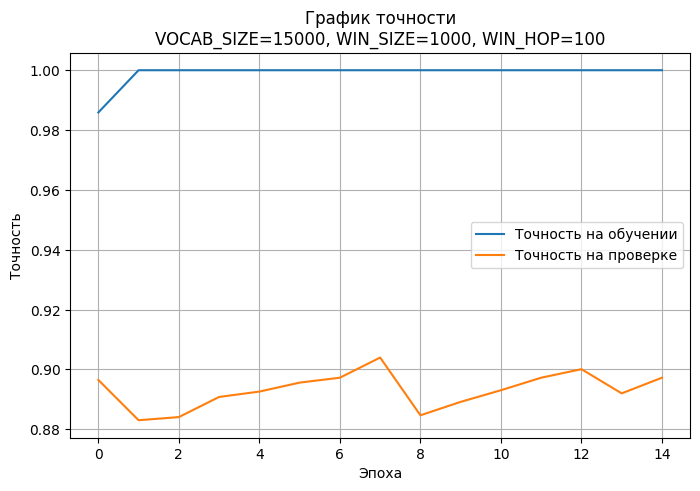

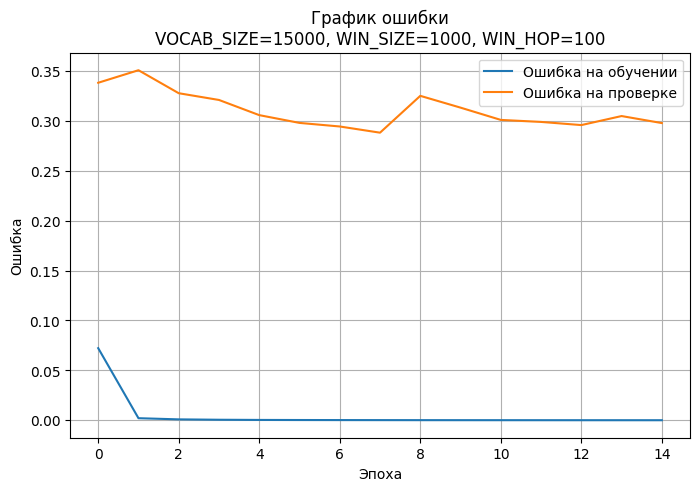

Лучшая точность: 0.9039784624588693


In [ ]:
VOCAB_SIZE = 15000
WIN_SIZE = 1000
WIN_HOP = 100

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 15000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_01: (7047, 15000)
y_train: (7047,)
x_test_01: (2664, 15000)
y_test: (2664,)
Эпоха 1/15 | точность: 0.96906 | проверка: 0.89640 | ошибка: 0.15423 | ошибка проверки: 0.38462
Эпоха 2/15 | точность: 1.00000 | проверка: 0.91141 | ошибка: 0.00628 | ошибка проверки: 0.32742
Эпоха 3/15 | точность: 0.99986 | проверка: 0.92568 | ошибка: 0.00334 | ошибка проверки: 0.28487
Эпоха 4/15 | точность: 0.99943 | проверка: 0.91629 | ошибка: 0.00574 | ошибка проверки: 0.31576
Эпоха 5/15 | точность: 1.00000 | проверка: 0.90353 | ошибка: 0.00172 | ошибка проверки: 0.31332
Эпоха 6/15 | точность: 1.00000 | проверка: 0.90953 | ошибка: 0.00128 | ошибка проверки: 0.30370
Эпоха 7/15 | точность: 1.00000 | проверка: 0.88514 | ошибка: 0.00095 | ошибка проверки: 0.34372
Эпоха 8/15 | точность: 1.00000 | проверка: 0.88776 | ошибка: 0.00070 | ошибка проверки: 0.32279
Эпоха 9/15 | точность: 1.00000 | проверка: 0.88251 | ошибка: 0.00060 | ошибка проверки: 0.33378
Эпоха 

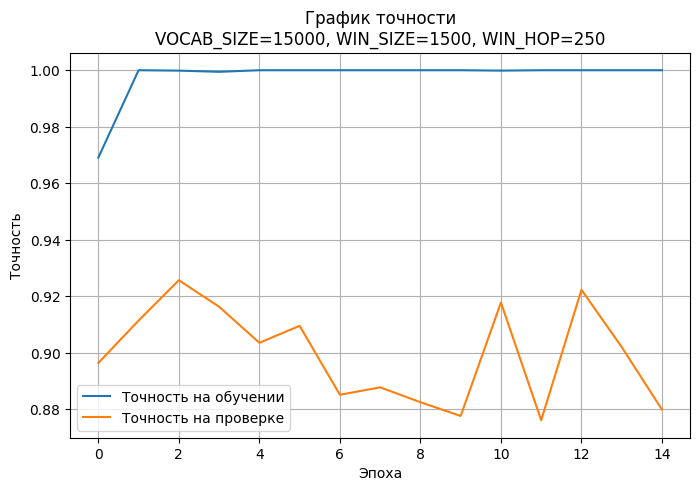

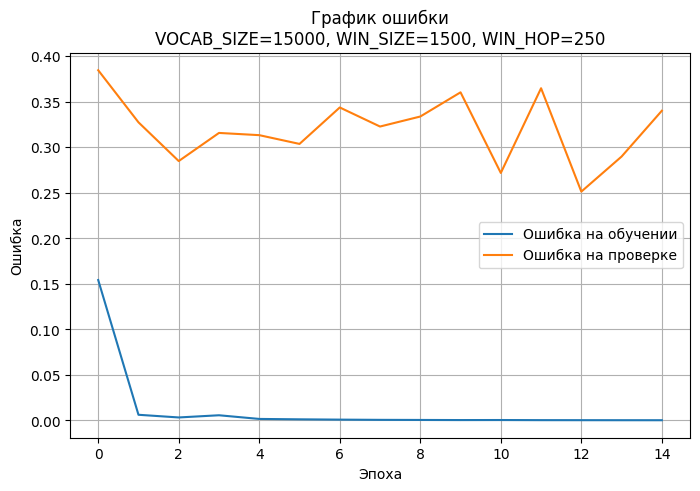

Лучшая точность: 0.9256756756756757


In [ ]:
VOCAB_SIZE = 15000
WIN_SIZE = 1500
WIN_HOP = 250

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 15000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_01: (3520, 15000)
y_train: (3520,)
x_test_01: (1328, 15000)
y_test: (1328,)
Эпоха 1/15 | точность: 0.94517 | проверка: 0.91416 | ошибка: 0.24335 | ошибка проверки: 0.39454
Эпоха 2/15 | точность: 1.00000 | проверка: 0.93449 | ошибка: 0.01312 | ошибка проверки: 0.32200
Эпоха 3/15 | точность: 1.00000 | проверка: 0.93675 | ошибка: 0.00628 | ошибка проверки: 0.29895
Эпоха 4/15 | точность: 1.00000 | проверка: 0.93599 | ошибка: 0.00431 | ошибка проверки: 0.28216
Эпоха 5/15 | точность: 1.00000 | проверка: 0.93599 | ошибка: 0.00310 | ошибка проверки: 0.26929
Эпоха 6/15 | точность: 1.00000 | проверка: 0.94051 | ошибка: 0.00226 | ошибка проверки: 0.25710
Эпоха 7/15 | точность: 1.00000 | проверка: 0.93373 | ошибка: 0.00192 | ошибка проверки: 0.26449
Эпоха 8/15 | точность: 1.00000 | проверка: 0.93976 | ошибка: 0.00161 | ошибка проверки: 0.24731
Эпоха 9/15 | точность: 1.00000 | проверка: 0.94352 | ошибка: 0.00127 | ошибка проверки: 0.24239
Эпоха 

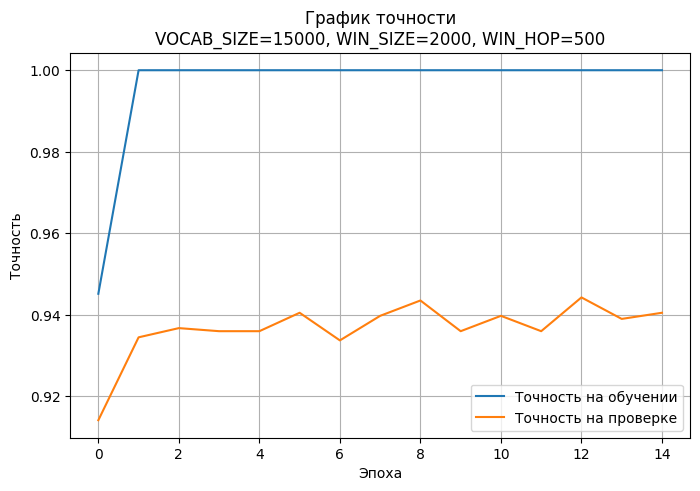

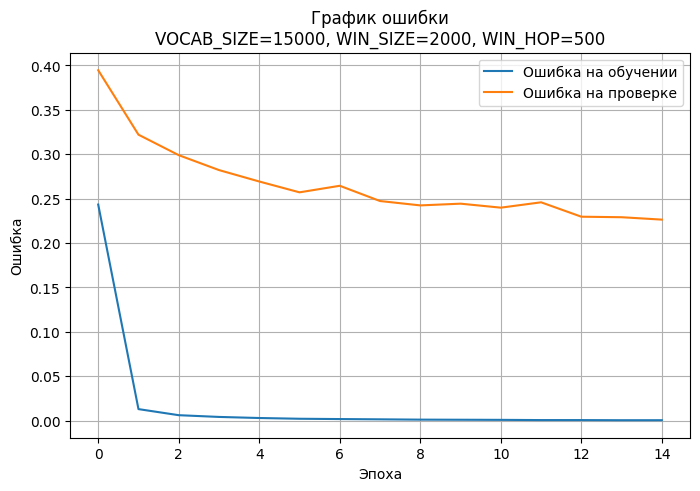

Лучшая точность: 0.9442771084337349


In [ ]:
VOCAB_SIZE = 15000
WIN_SIZE = 2000
WIN_HOP = 500

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 20000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_01: (17641, 20000)
y_train: (17641,)
x_test_01: (6686, 20000)
y_test: (6686,)
Эпоха 1/15 | точность: 0.98617 | проверка: 0.90607 | ошибка: 0.07116 | ошибка проверки: 0.32947
Эпоха 2/15 | точность: 1.00000 | проверка: 0.89964 | ошибка: 0.00191 | ошибка проверки: 0.31669
Эпоха 3/15 | точность: 1.00000 | проверка: 0.89261 | ошибка: 0.00086 | ошибка проверки: 0.32921
Эпоха 4/15 | точность: 1.00000 | проверка: 0.90712 | ошибка: 0.00051 | ошибка проверки: 0.29036
Эпоха 5/15 | точность: 1.00000 | проверка: 0.89381 | ошибка: 0.00033 | ошибка проверки: 0.31933
Эпоха 6/15 | точность: 1.00000 | проверка: 0.90084 | ошибка: 0.00025 | ошибка проверки: 0.29997
Эпоха 7/15 | точность: 1.00000 | проверка: 0.90951 | ошибка: 0.00020 | ошибка проверки: 0.27185
Эпоха 8/15 | точность: 1.00000 | проверка: 0.91101 | ошибка: 0.00014 | ошибка проверки: 0.27904
Эпоха 9/15 | точность: 1.00000 | проверка: 0.90473 | ошибка: 0.00012 | ошибка проверки: 0.29095
Эпох

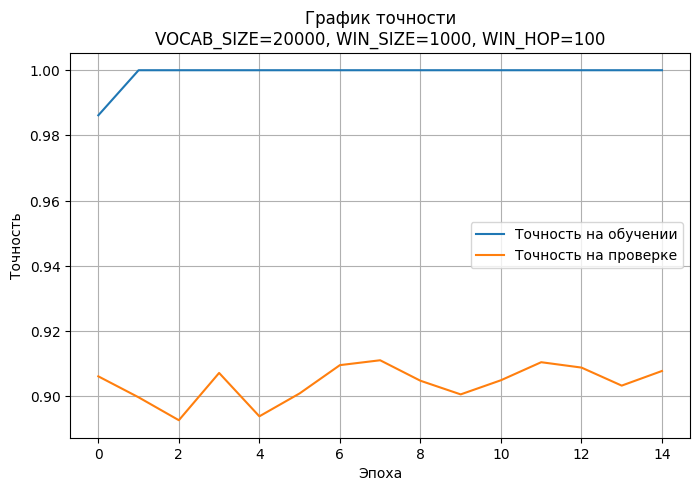

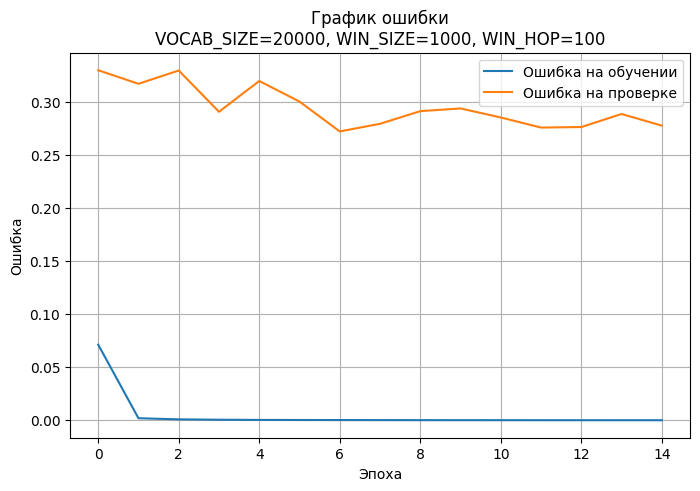

Лучшая точность: 0.911008076577924


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 1000
WIN_HOP = 100

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 20000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_01: (7047, 20000)
y_train: (7047,)
x_test_01: (2664, 20000)
y_test: (2664,)
Эпоха 1/15 | точность: 0.97020 | проверка: 0.90128 | ошибка: 0.15230 | ошибка проверки: 0.36779
Эпоха 2/15 | точность: 1.00000 | проверка: 0.91892 | ошибка: 0.00615 | ошибка проверки: 0.31685
Эпоха 3/15 | точность: 1.00000 | проверка: 0.90803 | ошибка: 0.00311 | ошибка проверки: 0.32417
Эпоха 4/15 | точность: 1.00000 | проверка: 0.92905 | ошибка: 0.00186 | ошибка проверки: 0.27087
Эпоха 5/15 | точность: 1.00000 | проверка: 0.91854 | ошибка: 0.00137 | ошибка проверки: 0.29493
Эпоха 6/15 | точность: 1.00000 | проверка: 0.90653 | ошибка: 0.00096 | ошибка проверки: 0.29161
Эпоха 7/15 | точность: 0.99986 | проверка: 0.92042 | ошибка: 0.00109 | ошибка проверки: 0.26114
Эпоха 8/15 | точность: 1.00000 | проверка: 0.92868 | ошибка: 0.00065 | ошибка проверки: 0.24252
Эпоха 9/15 | точность: 1.00000 | проверка: 0.92718 | ошибка: 0.00053 | ошибка проверки: 0.25116
Эпоха 

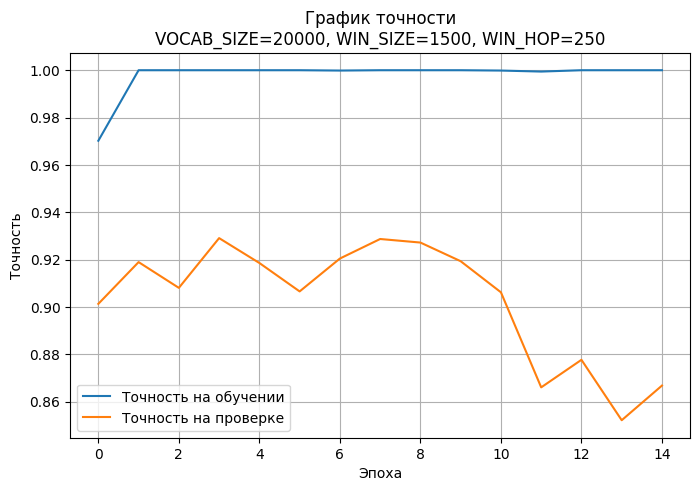

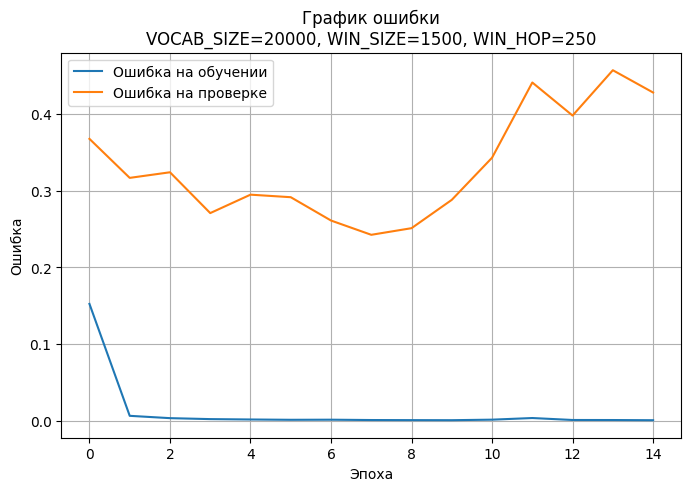

Лучшая точность: 0.9290540540540541


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 1500
WIN_HOP = 250

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

VOCAB_SIZE: 20000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_01: (3520, 20000)
y_train: (3520,)
x_test_01: (1328, 20000)
y_test: (1328,)
Эпоха 1/15 | точность: 0.95312 | проверка: 0.92771 | ошибка: 0.24161 | ошибка проверки: 0.36911
Эпоха 2/15 | точность: 1.00000 | проверка: 0.92696 | ошибка: 0.01320 | ошибка проверки: 0.30653
Эпоха 3/15 | точность: 1.00000 | проверка: 0.92470 | ошибка: 0.00601 | ошибка проверки: 0.29615
Эпоха 4/15 | точность: 1.00000 | проверка: 0.93373 | ошибка: 0.00400 | ошибка проверки: 0.27748
Эпоха 5/15 | точность: 1.00000 | проверка: 0.92997 | ошибка: 0.00270 | ошибка проверки: 0.27436
Эпоха 6/15 | точность: 1.00000 | проверка: 0.92922 | ошибка: 0.00236 | ошибка проверки: 0.27204
Эпоха 7/15 | точность: 1.00000 | проверка: 0.92545 | ошибка: 0.00184 | ошибка проверки: 0.26695
Эпоха 8/15 | точность: 1.00000 | проверка: 0.92319 | ошибка: 0.00147 | ошибка проверки: 0.26731
Эпоха 9/15 | точность: 1.00000 | проверка: 0.92244 | ошибка: 0.00122 | ошибка проверки: 0.27015
Эпоха 

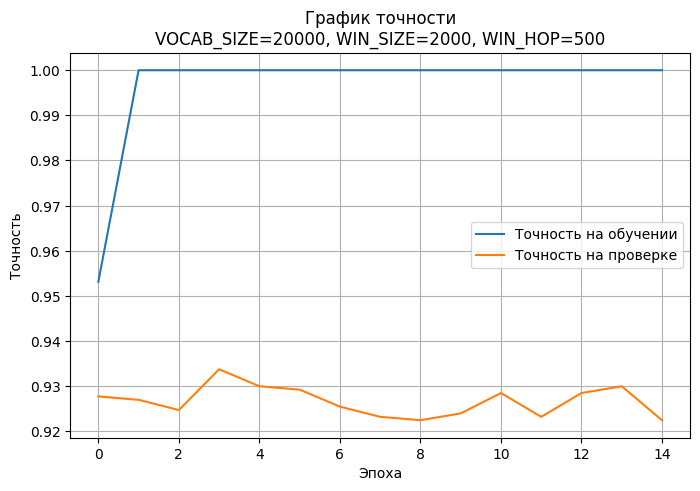

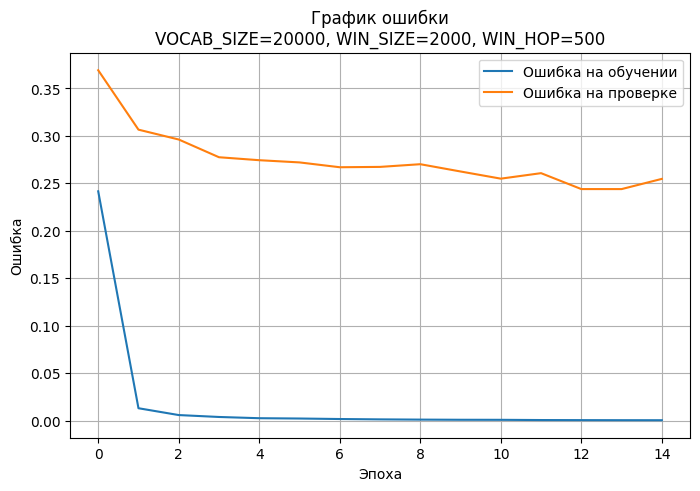

Лучшая точность: 0.9337349397590361


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 2000
WIN_HOP = 500

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)

train_loader, test_loader = create_loaders(x_train_01, y_train, x_test_01, y_test, batch_size=128)

model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))

history = train_model(model, train_loader, test_loader, epochs=15, learning_rate=0.001)

best_val_accuracy = max(history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history['accuracy'][-1],
  'Точность на проверке': history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history['val_accuracy']),
  'Ошибка на обучении': history['loss'][-1],
  'Ошибка на проверке': history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history['val_loss'])
})

In [ ]:
results_df = pd.DataFrame(results)

results_df

,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Точность на обучении,Точность на проверке,Лучшая точность на проверке,Ошибка на обучении,Ошибка на проверке,Лучшая ошибка на проверке
0,10000,1000,100,1.0,0.898594,0.903380,0.000047,0.298448,0.276442
1,10000,1500,250,1.0,0.894520,0.930931,0.000249,0.299976,0.240408
2,10000,2000,500,1.0,0.911145,0.920181,0.000702,0.287927,0.267999
3,15000,1000,100,1.0,0.897248,0.903978,0.000046,0.297804,0.288178
4,15000,1500,250,1.0,0.879880,0.925676,0.000298,0.340119,0.251326
5,15000,2000,500,1.0,0.940512,0.944277,0.000635,0.226395,0.226395
6,20000,1000,100,1.0,0.907718,0.911008,0.000044,0.277318,0.271852
7,20000,1500,250,1.0,0.866742,0.929054,0.000407,0.428306,0.242516
8,20000,2000,500,1.0,0.922440,0.933735,0.000577,0.254705,0.243944
